In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
load_dotenv()

# Load csv file.
sales_df = pd.read_csv("C:/Users/hp/Downloads/SuperStoreOrders.csv/SuperStoreOrders.csv")

print(sales_df.dtypes)

#  Handling null values.

order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales                 str
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year                int64
dtype: object


In [2]:
# changing order_date & ship_date column from str to datetime.
sales_df['order_date'] = pd.to_datetime(
     sales_df['order_date'],
     format='mixed',
     dayfirst=True,
     errors='coerce'
)

sales_df['ship_date'] = pd.to_datetime(
    sales_df['ship_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [3]:
# check datetime conversion.
print(sales_df[['order_date', 'ship_date']].head())

  order_date  ship_date
0 2011-01-01 2011-01-06
1 2011-01-01 2011-01-08
2 2011-01-01 2011-01-05
3 2011-01-01 2011-01-05
4 2011-01-01 2011-01-08


In [4]:
print(sales_df.dtypes)

order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                        str
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority               str
year                       int64
dtype: object


In [5]:
# generating sql table.
def generate_create_table(sales_df, table_name):
    columns = []

    for col, dtype in sales_df.dtypes.items():
        print(col, dtype)   # 🔍 debug line

        if pd.api.types.is_integer_dtype(dtype):
            sql_type = 'INT'
        elif pd.api.types.is_float_dtype(dtype):
            sql_type = 'FLOAT'
        elif pd.api.types.is_datetime64_any_dtype(dtype):
            sql_type = 'DATETIME'
        else:
            sql_type = 'VARCHAR(255)'

        columns.append(f"{col} {sql_type}")

    query = f"CREATE TABLE {table_name} (\n  " + ",\n  ".join(columns) + "\n);"
    return query

In [63]:
# Connecting mysql.
password = os.getenv("MYSQL_PASSWORD")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password= password,
    database="superstoreorders"
)
print("Connected successfully")
cursor = conn.cursor()



Connected successfully


In [7]:
# TAble Execution.
cursor.execute("DROP TABLE IF EXISTS orders;")
create_query = generate_create_table(sales_df, "orders")
cursor.execute(create_query)
conn.commit()
print('Table created successfully')

order_id str
order_date datetime64[us]
ship_date datetime64[us]
ship_mode str
customer_name str
segment str
state str
country str
market str
region str
product_id str
category str
sub_category str
product_name str
sales str
quantity int64
discount float64
profit float64
shipping_cost float64
order_priority str
year int64
Table created successfully


In [8]:
# Database verification.
cursor.execute("SELECT DATABASE();")
print(cursor.fetchone())

('superstoreorders',)


In [9]:
cursor.execute("DESCRIBE orders;")
print(cursor.fetchall())

[('order_id', 'varchar(255)', 'YES', '', None, ''), ('order_date', 'datetime', 'YES', '', None, ''), ('ship_date', 'datetime', 'YES', '', None, ''), ('ship_mode', 'varchar(255)', 'YES', '', None, ''), ('customer_name', 'varchar(255)', 'YES', '', None, ''), ('segment', 'varchar(255)', 'YES', '', None, ''), ('state', 'varchar(255)', 'YES', '', None, ''), ('country', 'varchar(255)', 'YES', '', None, ''), ('market', 'varchar(255)', 'YES', '', None, ''), ('region', 'varchar(255)', 'YES', '', None, ''), ('product_id', 'varchar(255)', 'YES', '', None, ''), ('category', 'varchar(255)', 'YES', '', None, ''), ('sub_category', 'varchar(255)', 'YES', '', None, ''), ('product_name', 'varchar(255)', 'YES', '', None, ''), ('sales', 'varchar(255)', 'YES', '', None, ''), ('quantity', 'int', 'YES', '', None, ''), ('discount', 'float', 'YES', '', None, ''), ('profit', 'float', 'YES', '', None, ''), ('shipping_cost', 'float', 'YES', '', None, ''), ('order_priority', 'varchar(255)', 'YES', '', None, ''), (

In [10]:
sales_df['order_date'] = sales_df['order_date'].dt.to_pydatetime()
sales_df['ship_date'] = sales_df['ship_date'].dt.to_pydatetime()

In [11]:
# prepare date to inset in mysql.

data = sales_df.values.tolist()

In [12]:
placeholders = ", ".join(["%s"] * len(sales_df.columns))
insert_query = f" INSERT INTO orders VALUES ({placeholders})"

In [13]:
# bulk insert.
cursor.executemany(insert_query, data)
conn.commit()
print("Data inserted successfully")

Data inserted successfully


In [14]:
# verifying inserted data.
cursor.execute("SELECT COUNT(*) FROM orders;")
print(cursor.fetchone())

(51290,)


In [15]:
# Total sales by category.

query = """
        SELECT category, SUM(sales) AS total_sales
        FROM orders
        GROUP BY category"""

sales_df = pd.read_sql(query, conn)
print(sales_df.head())

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3980032948.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


          category  total_sales
0  Office Supplies    2791051.0
1        Furniture    2407930.0
2       Technology    2639942.0


In [16]:
# Total profit by region and category.
query = """
SELECT
        region,
        category,
        SUM(profit) AS total_profit
FROM orders
GROUP BY region, category
ORDER BY region
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\4089652983.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


            region         category   total_profit
0           Africa        Furniture   16262.085136
1           Africa  Office Supplies   28480.053063
2           Africa       Technology   44129.493270
3           Canada        Furniture    2613.240007
4           Canada  Office Supplies    7957.530021
5           Canada       Technology    7246.620040
6        Caribbean        Furniture    6223.459942
7        Caribbean  Office Supplies   14818.276010
8        Caribbean       Technology   13529.585014
9          Central        Furniture   54550.840048
10         Central  Office Supplies  121314.720820
11         Central       Technology  135538.420294
12    Central Asia        Furniture   48935.711711
13    Central Asia  Office Supplies   27104.499831
14    Central Asia       Technology   56439.974662
15            East        Furniture    3046.165760
16            East  Office Supplies   41014.578978
17            East       Technology   47462.035078
18            EMEA        Furni

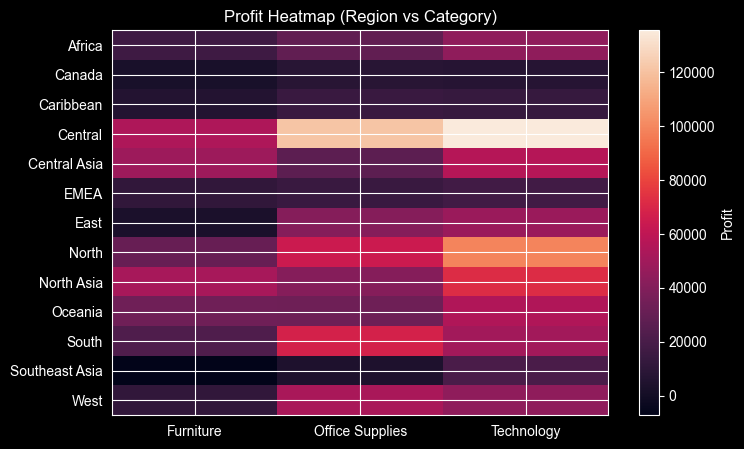

In [17]:
# Total profit by region and category Graph.
# pivot
pivot_df = sales_df.pivot(index='region', columns='category', values='total_profit')

plt.figure(figsize=(8,5))

plt.imshow(pivot_df, aspect='auto')

plt.colorbar(label='Profit')

plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
plt.yticks(range(len(pivot_df.index)), pivot_df.index)

plt.title('Profit Heatmap (Region vs Category)')

plt.show()

In [18]:
print(""" ### 📊 Insights

- Technology performs consistently well across most regions
- Furniture shows weak performance in multiple regions
- Some regions depend heavily on a single category
- Indicates imbalance in product distribution strategy
""")

 ### 📊 Insights

- Technology performs consistently well across most regions
- Furniture shows weak performance in multiple regions
- Some regions depend heavily on a single category
- Indicates imbalance in product distribution strategy



In [19]:
# Count of orders per Customer.

query = """
        SELECT order_id, customer_name, COUNT( order_id) AS total_orders
        FROM orders
        GROUP BY order_id, customer_name
        ORDER BY total_orders DESC
        """
sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\2105060746.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


              order_id      customer_name  total_orders
0       CA-2014-100111        Seth Vernon            14
1       MX-2014-166541    Patrick O'Brill            13
2         TO-2014-9950          Ann Blume            13
3        IN-2013-42311        Maya Herman            13
4         NI-2014-8880       Tamara Chand            13
...                ...                ...           ...
25748   CA-2013-137939    Pauline Johnson             1
25749   MX-2013-148012  Patricia Hirasaki             1
25750  ES-2013-2447615          Joy Bell-             1
25751    ID-2013-29662      Evan Bailliet             1
25752   MX-2013-169194      Thea Hudgings             1

[25753 rows x 3 columns]


In [20]:
# Top 5 Customer by sales

query = """
       SELECT order_id, customer_name, SUM(sales) AS total_sales
       FROM orders
       GROUP BY order_id, customer_name
       ORDER BY total_sales DESC
       LIMIT 5
       """
sales_df = pd.read_sql(query, conn)
print(sales_df)

          order_id      customer_name  total_sales
0   MX-2012-137561       Luke Schmidt       3381.0
1  ES-2014-1080192       Mathew Reese       3199.0
2  ES-2014-2271414  Alan Schoenberger       3176.0
3   MX-2013-134453      Raymond Messe       3117.0
4    IN-2012-72229       Dario Medina       3026.0


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\451003357.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [21]:
# Top customer per region.

query = """
       SELECT region, order_id, customer_name, SUM(sales) AS total_sales
       FROM orders
       GROUP BY region, order_id, customer_name
       ORDER BY total_sales DESC
       """
sales_df = pd.read_sql(query, conn)
top_customer_per_region = (sales_df.sort_values(['region', 'total_sales'], ascending=[True, False])
                           .groupby('region').head(1) )
print(top_customer_per_region)


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\4175331073.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


             region         order_id       customer_name  total_sales
20           Africa     IV-2014-5410          Barry Pond       2547.0
287          Canada     CA-2014-3540        Trudy Glocke       1561.0
29        Caribbean   MX-2013-138373        Ralph Arnett       2422.0
1           Central  ES-2014-1080192        Mathew Reese       3199.0
13     Central Asia    IN-2013-64452     Katharine Harms       2772.0
27             EMEA     SA-2013-7790      Randy Ferguson       2448.0
19             East   US-2013-114013  Stewart Carmichael       2551.0
7             North  ES-2014-2756281        Mitch Webber       2962.0
15       North Asia    IN-2012-74049          Ben Ferrer       2692.0
4           Oceania    IN-2012-72229        Dario Medina       3026.0
0             South   MX-2012-137561        Luke Schmidt       3381.0
5    Southeast Asia    IN-2012-41261     Ted Butterfield       3003.0
6              West   CA-2014-161956     Dan Reichenbach       2971.0


In [22]:
# total profit by categories.

query = """
        SELECT category, SUM(profit) AS total_profit
        FROM orders
        GROUP BY category"""

sales_df = pd.read_sql(query, conn)
print(sales_df)

          category   total_profit
0  Office Supplies  518473.833515
1        Furniture  286782.253436
2       Technology  663778.733210


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3157805670.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


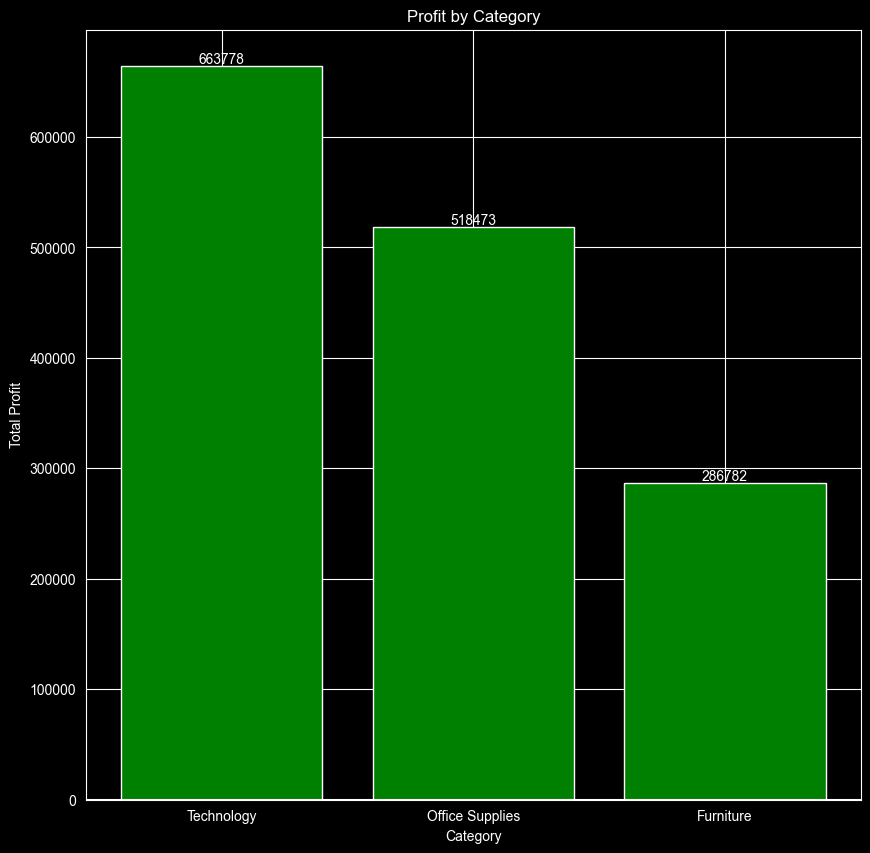

In [23]:
# profit by categories Bar Graph.


sales_df = sales_df.sort_values(by='total_profit', ascending=False)

plt.figure(figsize=(10,10))

colors = ['green' if x > 0 else 'red' for x in sales_df['total_profit']]

bars = plt.bar(sales_df['category'], sales_df['total_profit'], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.axhline(0)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.show()

In [24]:
print(""" INSIGHTS
- Technology generates highest profit.
- Furniture shows lower profitability.
- Profit distribution is uneven.
""")

 INSIGHTS
- Technology generates highest profit.
- Furniture shows lower profitability.
- Profit distribution is uneven.



In [25]:
# Top 3 sub-categories by profit in each category.

query = """
        SELECT category,sub_category,  SUM(profit) AS total_profit
        FROM orders
        GROUP BY  category,sub_category
        ORDER BY category, total_profit DESC
       """
sales_df = pd.read_sql(query, conn)
top3 = sales_df.groupby('category').head(3)
print(top3)

           category sub_category   total_profit
0         Furniture    Bookcases  161924.419883
1         Furniture       Chairs  141973.797120
2         Furniture  Furnishings   46967.425348
4   Office Supplies   Appliances  141680.589207
5   Office Supplies      Storage  108461.489520
6   Office Supplies      Binders   72449.846136
13       Technology      Copiers  258567.548228
14       Technology       Phones  216717.006160
15       Technology  Accessories  129626.306129


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\674945588.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


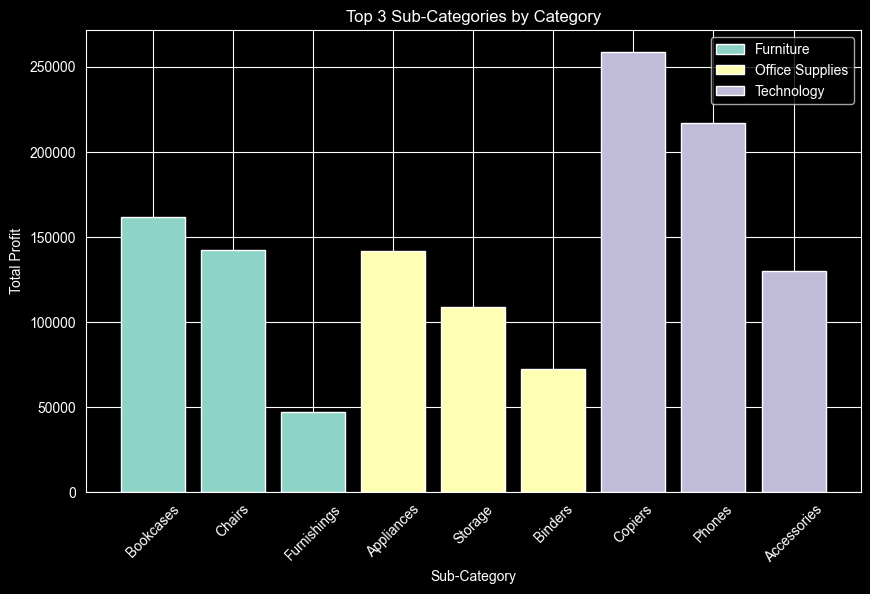

In [26]:
# Sub-Category Graph.
plt.figure(figsize=(10,6))

for cat in top3['category'].unique():
    subset = top3[top3['category'] == cat]
    plt.bar(subset['sub_category'], subset['total_profit'], label=cat)

plt.title('Top 3 Sub-Categories by Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [27]:
print("""### 📊 Insights

- Profit within each category is highly concentrated in a few sub-categories.
- Top 3 sub-categories contribute the majority of profit in their respective categories.
- This indicates that not all products perform equally within a category.
- Business should focus on promoting and stocking high-performing sub-categories.
- Underperforming sub-categories may need pricing, marketing, or inventory optimization.
""")

### 📊 Insights

- Profit within each category is highly concentrated in a few sub-categories.
- Top 3 sub-categories contribute the majority of profit in their respective categories.
- This indicates that not all products perform equally within a category.
- Business should focus on promoting and stocking high-performing sub-categories.
- Underperforming sub-categories may need pricing, marketing, or inventory optimization.



In [28]:
# total loss by categories.

query = """
        SELECT category, SUM(profit) AS total_loss
        FROM orders
        WHERE profit < 0
        GROUP BY category
        """

sales_df = pd.read_sql(query, conn)
print(sales_df)

          category     total_loss
0  Office Supplies -263981.917803
1       Technology -286495.398238
2        Furniture -369880.074813


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\1887151312.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


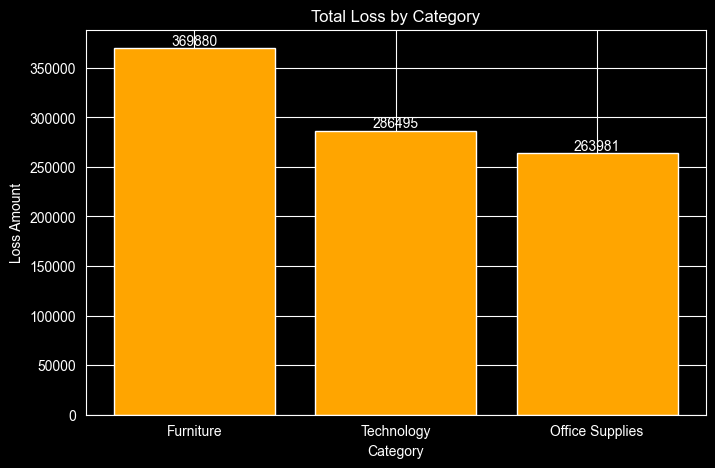

In [29]:
# total loss by categories Graph.

# Convert to positive values
sales_df['total_loss'] = sales_df['total_loss'].abs()

sales_df = sales_df.sort_values(by='total_loss', ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(sales_df['category'], sales_df['total_loss'], color='orange')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Total Loss by Category')
plt.xlabel('Category')
plt.ylabel('Loss Amount')

plt.show()

In [30]:
print(""" INSIGHTS
• Furniture category contributes highest losses
• Losses indicate inefficient pricing or heavy discounting
• Need optimization in loss-heavy categories
""")

 INSIGHTS
• Furniture category contributes highest losses
• Losses indicate inefficient pricing or heavy discounting
• Need optimization in loss-heavy categories



In [31]:
# Worst performing products.

query = """
SELECT
      product_name,
      SUM(profit) AS net_profit,
      SUM(CASE WHEN profit < 0 THEN profit ELSE 0 END) AS total_loss
FROM orders
GROUP BY product_name
ORDER BY net_profit ASC
LIMIT 5
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

                                product_name   net_profit   total_loss
0  Cubify CubeX 3D Printer Double Head Print -8879.970428 -9239.969238
1  Lexmark MX611dhe Monochrome Laser Printer -4589.972961 -5269.968933
2             Motorola Smart Phone, Cordless -4447.037979 -6511.937958
3  Cubify CubeX 3D Printer Triple Head Print -3839.990479 -3839.990479
4       Bevis Round Table, Adjustable Height -3649.893951 -3892.673950


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3306364465.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [32]:
# Net profit/loss and percentage.

query = """
SELECT
        category,
        SUM(profit) AS total_profit,
        SUM(CASE WHEN profit < 0 THEN profit ELSE 0 END) AS total_loss,
        SUM(profit)
          - ABS(SUM(CASE WHEN profit < 0 THEN profit ELSE 0 END)) AS net_profit,


         (ABS(SUM(CASE WHEN profit < 0 THEN profit ELSE 0 END))
         /  SUM(sales)) * 100 AS relative_loss_percentage

FROM orders
GROUP BY category"""

sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\1388056126.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


          category   total_profit     total_loss     net_profit  \
0  Office Supplies  518473.833515 -263981.917803  254491.915712   
1        Furniture  286782.253436 -369880.074813  -83097.821376   
2       Technology  663778.733210 -286495.398238  377283.334972   

   relative_loss_percentage  
0                  9.458155  
1                 15.360915  
2                 10.852337  


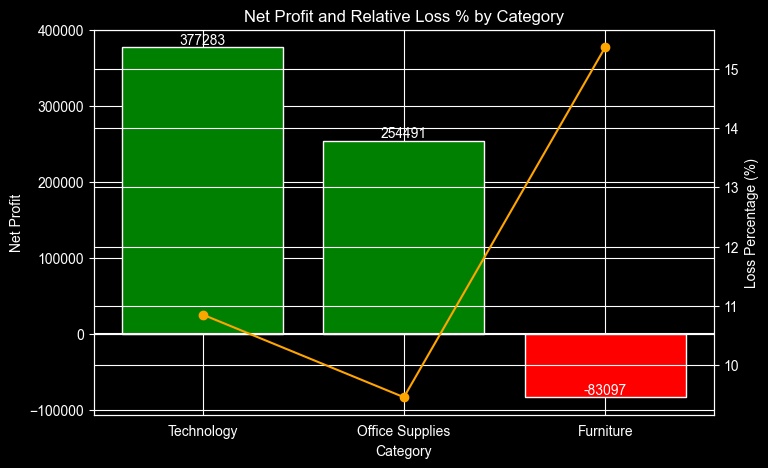

In [33]:
# Net profit/loss and percentage graph.

# Sorting data
sales_df = sales_df.sort_values(by='net_profit', ascending=False)

fig, ax1 = plt.subplots(figsize=(8,5))

# --- Bar chart (Net Profit) ---
colors = ['green' if x > 0 else 'red' for x in sales_df['net_profit']]
bars = ax1.bar(sales_df['category'], sales_df['net_profit'], color=colors)

ax1.set_xlabel('Category')
ax1.set_ylabel('Net Profit')
ax1.set_title('Net Profit and Relative Loss % by Category')
ax1.axhline(0)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

# --- Line chart (Loss %) ---
ax2 = ax1.twinx()
ax2.plot(sales_df['category'],
         sales_df['relative_loss_percentage'],
         color='orange',
         marker='o',
         label='Loss %')

ax2.set_ylabel('Loss Percentage (%)')

plt.show()

In [34]:
print(""" ### ### 📊 Insights

- Profitability and risk are not always aligned — some categories generate profit but still incur high losses.
- This indicates that revenue alone is not a reliable performance metric; cost and discount strategies must be considered.
- Categories with low loss % and stable profit are more sustainable for long-term growth.
- High loss % categories may benefit from pricing strategy revision or discount control.

""")

 ### ### 📊 Insights

- Profitability and risk are not always aligned — some categories generate profit but still incur high losses.
- This indicates that revenue alone is not a reliable performance metric; cost and discount strategies must be considered.
- Categories with low loss % and stable profit are more sustainable for long-term growth.
- High loss % categories may benefit from pricing strategy revision or discount control.




In [35]:
# Loss making sub categories.

query = """
        SELECT sub_category, SUM(profit) AS total_profit
        FROM orders
        GROUP BY sub_category
        HAVING total_profit < 0"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

  sub_category  total_profit
0       Tables -64083.388914


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\2864220128.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [36]:
# Average profit margin by category.

query = """
        SELECT category,
                AVG((profit/sales)*100) AS avg_profit_margin
        FROM orders
        WHERE sales != 0
        GROUP BY category"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

          category  avg_profit_margin
0  Office Supplies         332.555655
1        Furniture        1354.213802
2       Technology        2649.932241


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\416723881.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [37]:
# Monthly Sales Trend.

query = """
        SELECT
             DATE_FORMAT(order_date, '%Y-%m') AS month,
             SUM(sales) AS total_sales
        FROM orders
        GROUP BY month
        ORDER BY month ASC"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

      month  total_sales
0   2011-01      64390.0
1   2011-02      60873.0
2   2011-03      79041.0
3   2011-04      80726.0
4   2011-05      91580.0
5   2011-06     142583.0
6   2011-07      75443.0
7   2011-08     132126.0
8   2011-09     154103.0
9   2011-10     122915.0
10  2011-11     175321.0
11  2011-12     199758.0
12  2012-01      81627.0
13  2012-02      64701.0
14  2012-03     100945.0
15  2012-04     102715.0
16  2012-05     133143.0
17  2012-06     173822.0
18  2012-07      98343.0
19  2012-08     167294.0
20  2012-09     180680.0
21  2012-10     156025.0
22  2012-11     225257.0
23  2012-12     197722.0
24  2013-01     100831.0
25  2013-02      94206.0
26  2013-03     125766.0
27  2013-04     118262.0
28  2013-05     152619.0
29  2013-06     232754.0
30  2013-07     155735.0
31  2013-08     209263.0
32  2013-09     253309.0
33  2013-10     169325.0
34  2013-11     239668.0
35  2013-12     256306.0
36  2014-01     139164.0
37  2014-02     120370.0
38  2014-03     160972.0


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3078051295.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


Axes(0.125,0.11;0.775x0.77)


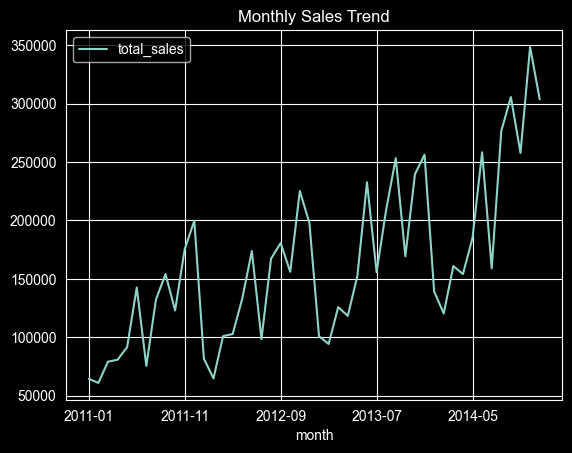

In [38]:
df =sales_df.plot(x='month', y='total_sales', kind='line', title='Monthly Sales Trend')
print(df)

In [39]:
print(""" INSIGHTS
• Sales show an overall upward trend over time
• Certain months show spikes → possible seasonal demand
• Some months show decline → potential low-demand periods
""")

 INSIGHTS
• Sales show an overall upward trend over time
• Certain months show spikes → possible seasonal demand
• Some months show decline → potential low-demand periods



In [40]:
# Total discount by categories and sub-categories.

query ="""
       SELECT
       category, sub_category,
       SUM(discount) AS total_discount,
       AVG(discount) AS avg_discount
       FROM orders
       GROUP BY category, sub_category
       """
sales_df = pd.read_sql(query, conn)
top_product_discount = (sales_df
                        .sort_values(['category', 'total_discount'], ascending=[True, False])
                        .groupby('category')
                        .head(3))
print(top_product_discount)

           category sub_category  total_discount  avg_discount
7         Furniture       Chairs      560.120011      0.163110
3         Furniture  Furnishings      478.880010      0.151066
9         Furniture    Bookcases      370.710004      0.153758
16  Office Supplies      Binders     1102.480005      0.179207
0   Office Supplies      Storage      700.490008      0.138464
13  Office Supplies          Art      573.080006      0.117362
10       Technology       Phones      489.610006      0.145847
11       Technology  Accessories      370.480003      0.120481
6        Technology      Copiers      260.418003      0.117147


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\1644784508.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [41]:
# Top 3 Customer per region.

query = """
WITH customer_sales AS (
    SELECT
         order_id,
         region,
         customer_name,
         SUM(sales) AS total_sales
    FROM orders
    GROUP BY order_id, region, customer_name
    )
SELECT *
FROM (
     SELECT *,
            ROW_NUMBER() OVER(
              PARTITION BY region
              ORDER BY total_sales DESC
              ) AS rank_customer
     FROM customer_sales
) t
WHERE rank_customer <= 3
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\576173324.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


           order_id          region       customer_name  total_sales  \
0      IV-2014-5410          Africa          Barry Pond       2547.0   
1      AG-2012-4630          Africa      Christine Phan       2365.0   
2      CG-2012-8310          Africa       Barry Weirich       2365.0   
3      CA-2014-3540          Canada        Trudy Glocke       1561.0   
4      CA-2011-1800          Canada        Tom Prescott       1344.0   
5       CA-2012-490          Canada           Janet Lee       1186.0   
6    MX-2013-138373       Caribbean        Ralph Arnett       2422.0   
7    MX-2014-128097       Caribbean     Kelly Collister       1972.0   
8    MX-2014-166254       Caribbean       Yana Sorensen       1842.0   
9   ES-2014-1080192         Central        Mathew Reese       3199.0   
10  ES-2014-2271414         Central   Alan Schoenberger       3176.0   
11   MX-2013-134453         Central       Raymond Messe       3117.0   
12    IN-2013-64452    Central Asia     Katharine Harms       27

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3049554528.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


           category  year  total_sales     net_profit  profit_margin_pct  \
0         Furniture  2011     428117.0   53696.926219          12.542582   
1         Furniture  2012     496207.0   58132.834227          11.715440   
2         Furniture  2013     677479.0   85640.430412          12.641046   
3         Furniture  2014     806127.0   89312.062579          11.079155   
4   Office Supplies  2011     492011.0   85996.534234          17.478580   
5   Office Supplies  2012     608187.0  103305.507815          16.985813   
6   Office Supplies  2013     744624.0  149245.735151          20.043100   
7   Office Supplies  2014     946229.0  179926.056316          19.015065   
8        Technology  2011     458731.0  109247.350784          23.815123   
9        Technology  2012     577880.0  145976.937206          25.260770   
10       Technology  2013     685941.0  173626.593261          25.312176   
11       Technology  2014     917390.0  234927.851959          25.608286   

    prev_sa

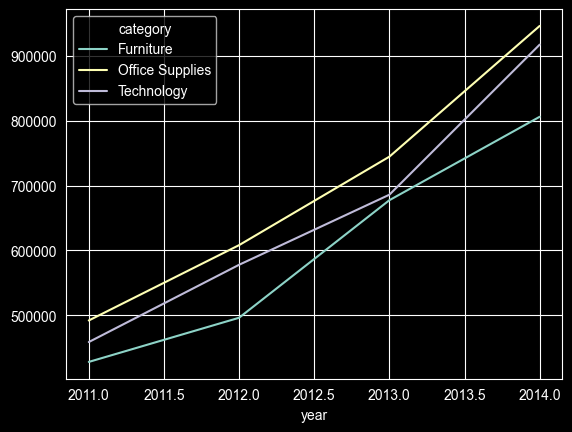

In [42]:
# Year over Year sales by category analysis.
query = """
SELECT
      category,
      year,
      total_sales,
      net_profit,

      (net_profit/total_sales) * 100 AS profit_margin_pct,

      COALESCE(prev_sales, 0) AS prev_sales,

      COALESCE(total_sales - prev_sales, 0) AS yoy_change,

      COALESCE(
          ((total_sales - prev_sales) / NULLIF(prev_sales, 0)) * 100,
      0) AS yoy_growth_pct,

      SUM(total_sales) OVER (PARTITION BY category ORDER BY year) AS cumulative_sales,

      RANK() OVER (PARTITION BY year ORDER BY total_sales DESC) AS rank_in_year

FROM (
     SELECT
          category,
          YEAR(order_date) AS year,
          SUM(sales) AS total_sales,
          SUM(profit) AS net_profit,
          LAG(SUM(sales)) OVER (PARTITION BY category ORDER BY YEAR(order_date)) AS prev_sales
     FROM orders
     GROUP BY category, YEAR(order_date)
) t
ORDER BY category, year
"""

sales_df = pd.read_sql(query, conn)
print(sales_df)
table = sales_df.pivot(index='year' , columns='category', values='total_sales').plot()
print(table)

In [43]:
print(""" ### 📊 Insights

- YoY growth highlights fluctuations in category performance, suggesting external factors like demand or promotions.
- Categories with stable growth and high profit margins are more sustainable for long-term business.
- High sales growth with declining profit margin may indicate aggressive discounting or rising costs.
- Ranking analysis shows competitive position of categories each year, helping identify market leaders.
""")

 ### 📊 Insights

- YoY growth highlights fluctuations in category performance, suggesting external factors like demand or promotions.
- Categories with stable growth and high profit margins are more sustainable for long-term business.
- High sales growth with declining profit margin may indicate aggressive discounting or rising costs.
- Ranking analysis shows competitive position of categories each year, helping identify market leaders.



In [44]:
# Duplicate customers in multiple regions.
query = """
SELECT
    customer_name,
    GROUP_CONCAT(DISTINCT region) AS regions,
    COUNT(DISTINCT region) AS region_count
FROM orders
GROUP BY customer_name
HAVING region_count > 1
ORDER BY region_count DESC
"""

sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\4009978963.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


            customer_name                                            regions  \
0               Adam Hart  Africa,Canada,Caribbean,Central,Central Asia,E...   
1    Alejandro Ballentine  Africa,Canada,Caribbean,Central,Central Asia,E...   
2         Alejandro Grove  Africa,Canada,Caribbean,Central,Central Asia,E...   
3         Andrew Gjertsen  Africa,Canada,Caribbean,Central,Central Asia,E...   
4            Art Ferguson  Africa,Canada,Caribbean,Central,Central Asia,E...   
..                    ...                                                ...   
790           Anna Gayman  Africa,Central,EMEA,North,Oceania,South,Southe...   
791           Dana Kaydos  Africa,Central,EMEA,North,South,Southeast Asia...   
792           Darren Budd        Africa,Central,East,EMEA,North,Oceania,West   
793          Peter Bühler   Central,East,EMEA,North,North Asia,Oceania,South   
794        Michael Oakman            Africa,Central,EMEA,North,Oceania,South   

     region_count  
0              13  

In [45]:
# Monthly Sales and Running total.

query ="""
SELECT
     month,
     total_sales,
     SUM(total_sales) OVER (ORDER BY month) AS running_total

FROM (
     SELECT
          DATE_FORMAT(order_date, '%Y-%m') AS month,
          SUM(sales) AS total_sales
     FROM orders
     GROUP BY DATE_FORMAT(order_date, '%Y-%m')
) t
ORDER BY month
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

      month  total_sales  running_total
0   2011-01      64390.0        64390.0
1   2011-02      60873.0       125263.0
2   2011-03      79041.0       204304.0
3   2011-04      80726.0       285030.0
4   2011-05      91580.0       376610.0
5   2011-06     142583.0       519193.0
6   2011-07      75443.0       594636.0
7   2011-08     132126.0       726762.0
8   2011-09     154103.0       880865.0
9   2011-10     122915.0      1003780.0
10  2011-11     175321.0      1179101.0
11  2011-12     199758.0      1378859.0
12  2012-01      81627.0      1460486.0
13  2012-02      64701.0      1525187.0
14  2012-03     100945.0      1626132.0
15  2012-04     102715.0      1728847.0
16  2012-05     133143.0      1861990.0
17  2012-06     173822.0      2035812.0
18  2012-07      98343.0      2134155.0
19  2012-08     167294.0      2301449.0
20  2012-09     180680.0      2482129.0
21  2012-10     156025.0      2638154.0
22  2012-11     225257.0      2863411.0
23  2012-12     197722.0      3061133.0


C:\Users\hp\AppData\Local\Temp\ipykernel_10440\1927579438.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [46]:
# Month over Month analysis and percentage change.
query ="""
WITH monthly_sales AS (
    SELECT
         DATE_FORMAT(order_date, '%Y-%m') AS month,
         SUM(sales) AS current_monthly_sales
    FROM orders
    GROUP BY DATE_FORMAT(order_date, '%Y-%m')
)
SELECT *,
     COALESCE(current_monthly_sales - previous_monthly_sales , 0) AS MoM_change,
     COALESCE(
           ROUND((current_monthly_sales - previous_monthly_sales)/
                NULLIF(previous_monthly_sales, 0)*100,2),0) AS MoM_change_pct

FROM (
     SELECT *,
            LAG(current_monthly_sales) OVER (ORDER BY month) AS previous_monthly_sales
     FROM monthly_sales
) t
ORDER BY month

"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3717700949.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


      month  current_monthly_sales  previous_monthly_sales  MoM_change  \
0   2011-01                64390.0                     NaN         0.0   
1   2011-02                60873.0                 64390.0     -3517.0   
2   2011-03                79041.0                 60873.0     18168.0   
3   2011-04                80726.0                 79041.0      1685.0   
4   2011-05                91580.0                 80726.0     10854.0   
5   2011-06               142583.0                 91580.0     51003.0   
6   2011-07                75443.0                142583.0    -67140.0   
7   2011-08               132126.0                 75443.0     56683.0   
8   2011-09               154103.0                132126.0     21977.0   
9   2011-10               122915.0                154103.0    -31188.0   
10  2011-11               175321.0                122915.0     52406.0   
11  2011-12               199758.0                175321.0     24437.0   
12  2012-01                81627.0    

<function matplotlib.pyplot.show(close=None, block=None)>

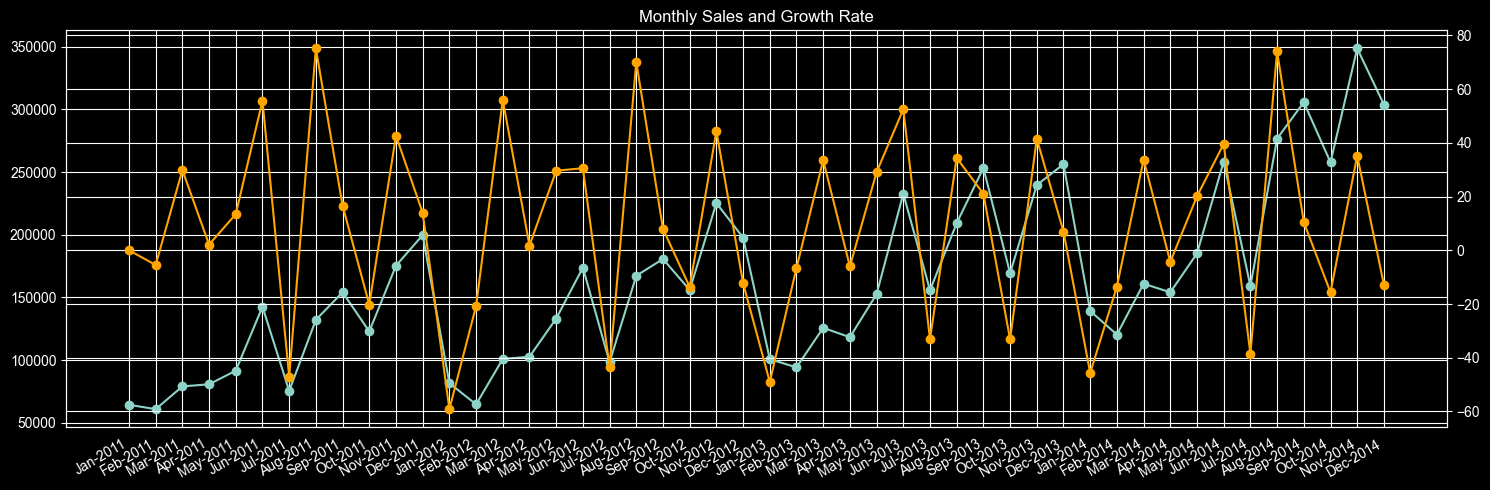

In [47]:
# Month over Month analysis and percentage change.
sales_df['month'] = pd.to_datetime(sales_df['month'])
sales_df['month'] = sales_df['month'].dt.strftime('%b-%Y')

fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(sales_df['month'], sales_df['current_monthly_sales'], marker='o')

ax2 = ax1.twinx()
ax2.plot(sales_df['month'], sales_df['MoM_change_pct'], color='orange', marker='o')

# Best formatting
fig.autofmt_xdate()

plt.title('Monthly Sales and Growth Rate')
plt.tight_layout()
plt.show

In [48]:
print(""" INSIGHTS
• High volatility in month-over-month growth
• Sudden spikes indicate promotional or seasonal impact
• Negative growth months highlight instability in sales
""")

 INSIGHTS
• High volatility in month-over-month growth
• Sudden spikes indicate promotional or seasonal impact
• Negative growth months highlight instability in sales



In [49]:
#  Contribution % of Top Customers.

query = """
WITH customer_sales AS(
SELECT
     region,
     customer_name,
     SUM(sales) AS customer_total_sales
FROM orders
GROUP BY region, customer_name
),

total_data AS(
SELECT *,
        SUM(customer_total_sales) over() AS total_sales
FROM customer_sales
)

SELECT *,
       ROUND((customer_total_sales / total_sales)*100,2) AS customer_pct_contribution
FROM total_data
ORDER BY customer_total_sales DESC
LIMIT 10
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

    region     customer_name  customer_total_sales  total_sales  \
0  Central      Mathew Reese                8541.0    7838923.0   
1    North      Eric Murdock                6769.0    7838923.0   
2  Central        Paul Prost                6524.0    7838923.0   
3  Central   Cynthia Delaney                6491.0    7838923.0   
4  Central   Roy Französisch                6477.0    7838923.0   
5    South     Maria Etezadi                6266.0    7838923.0   
6  Central      Carol Darley                6250.0    7838923.0   
7  Central     Tonja Turnell                6089.0    7838923.0   
8  Central  Katherine Murray                6059.0    7838923.0   
9  Central     Jeremy Pistek                5943.0    7838923.0   

   customer_pct_contribution  
0                       0.11  
1                       0.09  
2                       0.08  
3                       0.08  
4                       0.08  
5                       0.08  
6                       0.08  
7             

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\3844311071.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [50]:
# Sales spikes detection.

query ="""
WITH monthly_sales AS (
    SELECT
         DATE_FORMAT(order_date, '%Y-%m') AS month,
         SUM(sales) AS current_monthly_sales
    FROM orders
    GROUP BY DATE_FORMAT(order_date, '%Y-%m')
),

lag_data AS (
    SELECT *,
           LAG(current_monthly_sales) OVER (ORDER BY month) AS previous_monthly_sales
    FROM monthly_sales
),
final_data AS (
    SELECT *,
           COALESCE(current_monthly_sales - previous_monthly_sales, 0) AS MoM_change,

           COALESCE(
               ROUND((current_monthly_sales - previous_monthly_sales) /
               NULLIF(previous_monthly_sales, 0) * 100, 2),
           0) AS MoM_change_pct
    FROM lag_data
)

SELECT *
FROM final_data
ORDER BY month
"""
sales_df = pd.read_sql(query, conn)
print(sales_df)


      month  current_monthly_sales  previous_monthly_sales  MoM_change  \
0   2011-01                64390.0                     NaN         0.0   
1   2011-02                60873.0                 64390.0     -3517.0   
2   2011-03                79041.0                 60873.0     18168.0   
3   2011-04                80726.0                 79041.0      1685.0   
4   2011-05                91580.0                 80726.0     10854.0   
5   2011-06               142583.0                 91580.0     51003.0   
6   2011-07                75443.0                142583.0    -67140.0   
7   2011-08               132126.0                 75443.0     56683.0   
8   2011-09               154103.0                132126.0     21977.0   
9   2011-10               122915.0                154103.0    -31188.0   
10  2011-11               175321.0                122915.0     52406.0   
11  2011-12               199758.0                175321.0     24437.0   
12  2012-01                81627.0    

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\1016925508.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


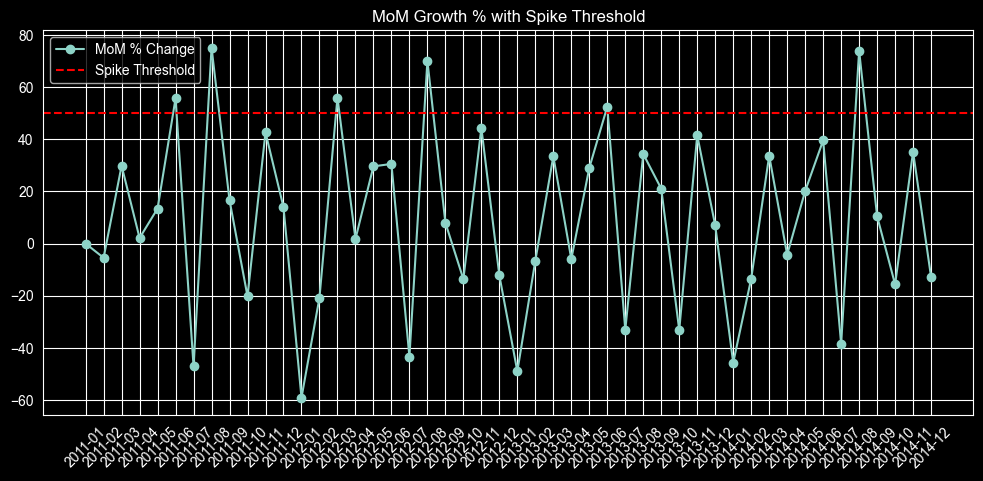

In [51]:
# Sales spikes detection.
plt.figure(figsize=(12,5))

plt.plot(sales_df['month'],
         sales_df['MoM_change_pct'],
         marker='o',
         label='MoM % Change')

# Threshold line
plt.axhline(50, color='red', linestyle='--', label='Spike Threshold')

plt.xticks(rotation=45)
plt.title('MoM Growth % with Spike Threshold')

plt.legend()
plt.show()

In [52]:
print(""" INSIGHTS
• Months exceeding 50% growth identified as spikes.
• Spikes are irregular → not consistent seasonality.
• Business should investigate drivers behind spike periods.
""")

 INSIGHTS
• Months exceeding 50% growth identified as spikes.
• Spikes are irregular → not consistent seasonality.
• Business should investigate drivers behind spike periods.



In [53]:
# Discount vs Profit .

query ="""
SELECT
      category,
      discount,
      AVG(profit) AS avg_profit,
      SUM(profit) AS total_profit
FROM orders
GROUP BY category, discount
ORDER BY category, discount"""

sales_df = pd.read_sql(query, conn)
print(sales_df)

           category  discount   avg_profit   total_profit
0         Furniture     0.000   103.561601  465612.956293
1         Furniture     0.070   141.488209    9762.686434
2         Furniture     0.100   102.765136  103176.196862
3         Furniture     0.150    27.288298    1418.991500
4         Furniture     0.200    19.035931   26574.159079
5         Furniture     0.250    12.942916    1630.807421
6         Furniture     0.270    -3.719108   -1078.541362
7         Furniture     0.300   -59.736982  -20011.888921
8         Furniture     0.320   -88.560655   -2391.137693
9         Furniture     0.350  -137.047281  -11237.877037
10        Furniture     0.370  -108.956375   -4031.385875
11        Furniture     0.400   -73.259026  -61464.322852
12        Furniture     0.450  -276.638662   -3596.302605
13        Furniture     0.470  -314.125740  -10680.275170
14        Furniture     0.500  -196.461968  -47347.334211
15        Furniture     0.550  -315.067201   -3150.672012
16        Furn

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\2185850686.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


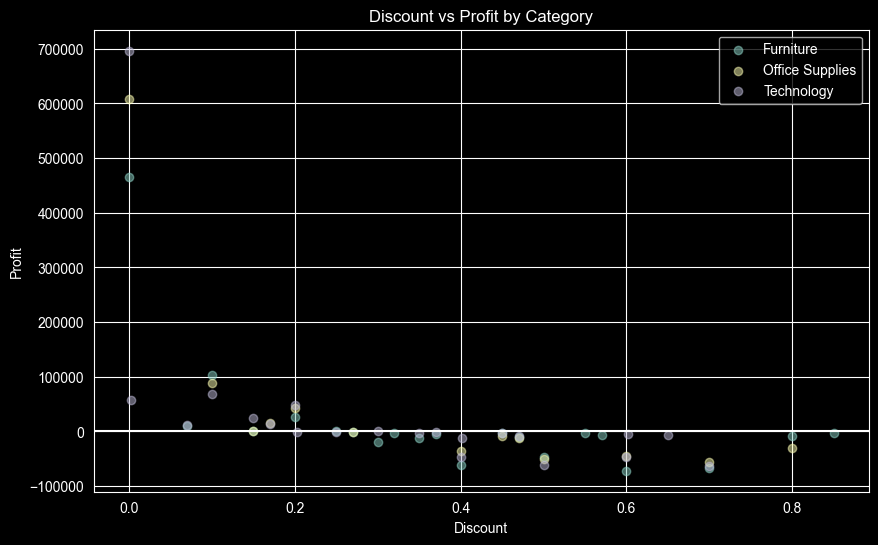

In [54]:
# Profit vs Discount Scatter graph.
plt.figure(figsize=(10,6))

categories = sales_df['category'].unique()

for cat in categories:
    subset = sales_df[sales_df['category'] == cat]
    plt.scatter(subset['discount'], subset['total_profit'], label=cat, alpha=0.5)

plt.axhline(0)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit by Category')
plt.legend()

plt.show()

In [55]:
print(""" INSIGHTS
• Higher discounts often reduce profitability.
• Some categories are highly sensitive to discounts.
• Aggressive discounting leads to losses in multiple cases.
""")

 INSIGHTS
• Higher discounts often reduce profitability.
• Some categories are highly sensitive to discounts.
• Aggressive discounting leads to losses in multiple cases.



In [56]:
# Customer segmentation

query ="""
WITH customer_sales AS(
SELECT
     region,
     customer_name,
     SUM(sales) AS customer_total_sales
FROM orders
GROUP BY region, customer_name
),

ranked AS (
       SELECT *,
              NTILE(3) OVER(PARTITION BY region ORDER BY customer_total_sales DESC) AS bucket
       FROM customer_sales
)

SELECT *,
       CASE
           WHEN bucket = 1 THEN 'High Value Customer'
           WHEN bucket = 2 THEN 'Mid Value Customer'
           ELSE 'Low Value Customer'
       END AS segment
FROM ranked
ORDER BY customer_total_sales DESC

 """

sales_df = pd.read_sql(query, conn)
print(sales_df)

              region        customer_name  customer_total_sales  bucket  \
0            Central         Mathew Reese                8541.0       1   
1              North         Eric Murdock                6769.0       1   
2            Central           Paul Prost                6524.0       1   
3            Central      Cynthia Delaney                6491.0       1   
4            Central      Roy Französisch                6477.0       1   
...              ...                  ...                   ...     ...   
8471         Oceania         Hunter Lopez                   1.0       3   
8472         Oceania       Mike Pelletier                   1.0       3   
8473         Oceania         Chad McGuire                   1.0       3   
8474         Oceania         Andrew Allen                   1.0       3   
8475  Southeast Asia  Marina Lichtenstein                   1.0       3   

                  segment  
0     High Value Customer  
1     High Value Customer  
2     High Valu

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\2449904868.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


In [57]:
print(""" INSIGHTS
• Top customers contribute majority of revenue.
• Customer base is unevenly distributed.
• High-value customers should be retained and targeted.
""")

 INSIGHTS
• Top customers contribute majority of revenue.
• Customer base is unevenly distributed.
• High-value customers should be retained and targeted.



In [58]:
#“Find top 20% customers contributing to 80% revenue (Pareto analysis)”

query ="""
WITH customer_profit AS(
   SELECT
      customer_name,
      SUM(profit) AS customer_total_profit
   FROM orders
   GROUP BY customer_name
   HAVING SUM(profit) > 0
),

profit_data AS(
  SELECT *,
       SUM(customer_total_profit) OVER() AS overall_profit,
       SUM(customer_total_profit) OVER(ORDER BY customer_total_profit DESC) AS cumulative_profit
  FROM customer_profit
)

SELECT *,
       ROUND((cumulative_profit/overall_profit)*100,2) AS Pareto_per
FROM profit_data
WHERE (cumulative_profit / overall_profit) * 100 <= 80
ORDER BY customer_total_profit DESC

"""
sales_df = pd.read_sql(query, conn)
print(sales_df)

        customer_name  customer_total_profit  overall_profit  \
0        Tamara Chand            8672.898445    1.534548e+06   
1        Raymond Buch            8453.049623    1.534548e+06   
2        Sanjit Chand            8205.379916    1.534548e+06   
3        Hunter Lopez            7816.567938    1.534548e+06   
4         Bill Eplett            7410.005279    1.534548e+06   
..                ...                    ...             ...   
422        Sung Chung            1696.698708    1.534548e+06   
423  Shahid Collister            1692.379749    1.534548e+06   
424    Fred Wasserman            1683.790382    1.534548e+06   
425  Stephanie Phelps            1682.805621    1.534548e+06   
426     Dave Hallsten            1681.868489    1.534548e+06   

     cumulative_profit  Pareto_per  
0         8.672898e+03        0.57  
1         1.712595e+04        1.12  
2         2.533133e+04        1.65  
3         3.314790e+04        2.16  
4         4.055790e+04        2.64  
..       

C:\Users\hp\AppData\Local\Temp\ipykernel_10440\2278876736.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


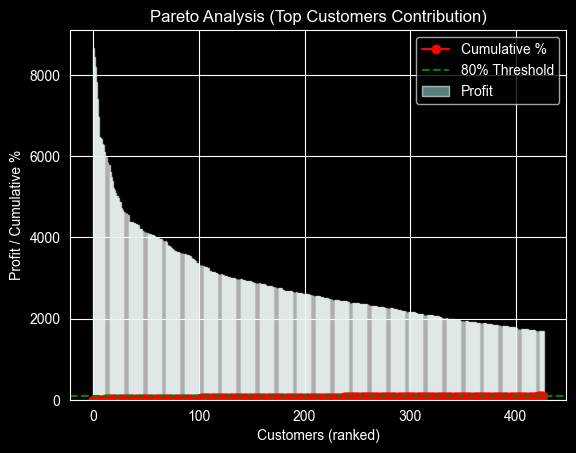

In [59]:
# Pareto analysis on profit chart.

# Sort data
df = sales_df.sort_values(by='customer_total_profit', ascending=False)

# Bar chart (profit)
plt.bar(range(len(df)), df['customer_total_profit'], alpha=0.6, label='Profit')

# Line chart (cumulative %)
plt.plot(range(len(df)), df['Pareto_per'], color='red', marker='o', label='Cumulative %')

# 80% line
plt.axhline(80, color='green', linestyle='--', label='80% Threshold')

# Labels
plt.xlabel('Customers (ranked)')
plt.ylabel('Profit / Cumulative %')
plt.title('Pareto Analysis (Top Customers Contribution)')
plt.legend()

plt.show()

In [60]:
print(""" INSIGHTS
• Top ~20% customers contribute ~80% of total profit.
• Business heavily depends on small customer group.
• Customer retention strategy is critical.
""")

 INSIGHTS
• Top ~20% customers contribute ~80% of total profit.
• Business heavily depends on small customer group.
• Customer retention strategy is critical.



In [61]:
print("""
## 📌 Strategic Conclusion

- Business performance is driven by a few key categories and customers, creating both opportunity and risk concentration
- Discounting strategy requires optimization, as excessive discounts are reducing overall profitability
- Growth is present but inconsistent, indicating a need for better demand planning and stability
- High-performing categories should be scaled, while underperforming ones require cost and pricing adjustments
- Customer-focused strategies (retention, loyalty programs) are critical due to dependence on top customers
""")


## 📌 Strategic Conclusion

- Business performance is driven by a few key categories and customers, creating both opportunity and risk concentration
- Discounting strategy requires optimization, as excessive discounts are reducing overall profitability
- Growth is present but inconsistent, indicating a need for better demand planning and stability
- High-performing categories should be scaled, while underperforming ones require cost and pricing adjustments
- Customer-focused strategies (retention, loyalty programs) are critical due to dependence on top customers

